# 🇨🇴 v2 — Series de Tiempo + Balance Energético del SIN

**Proyecto:** Energy Data Analysis Portfolio — Solar Generation Colombia   
**Notebook:** `02_serie_tiempo_balance_v2.ipynb`  
**Prerequisito:** Realizar la ejecución de forma previa del notebook `01_ETL_exploracion_v1.ipynb` (datos se almacenan en `data/raw/`)  
**Autor:** Manuel Fernando Fajardo Rodríguez

---

## 🎯 Objetivo

Extender el análisis de los datos obtenidos de la v1 integrando **demanda real**, **precio de bolsa**, **nivel de embalses** y **aportes hídricos** para construir una visión completa del **balance energético del SIN** para ventanas de tiempo de 30+ días. Este notebook queda además como la base de datos limpios que consumirá v2.5 (caso SAEB — Resolución CREG 101-113 de 2026).

### Preguntas que responde este notebook

1. **¿Cuál es el balance horario generación–demanda?** → ¿Hay excedentes o déficit? ¿A qué horas?
2. **¿Cómo responde el precio de bolsa a la composición de la generación?** → Correlación con participación térmica y nivel de embalses.
3. **¿Cuál es el estado de seguridad hídrica del sistema?** → Nivel de embalses, aportes, zonas de alerta.
4. **¿Existe una ventana de arbitraje para almacenamiento?** → Diferencial de precios pico/valle (input directo a v2.5 SAEB).

### Nuevas métricas de la API XM incorporadas

| MetricId | Nivel | Unidad | Descripción |
|:---------|:------|:-------|:------------|
| `DemaReal` | Sistema | kWh | Demanda real horaria del SIN |
| `PrecBolsNaci` | Sistema | COP/kWh | Precio de bolsa nacional horario |
| `PorcVoluUtilDiar` | Sistema | % | Nivel de embalses (% capacidad útil) |
| `AporEner` | Sistema | kWh | Aportes de energía hídrica al sistema |
| `PrecEsca` | Sistema | COP/kWh | Precio de escasez (umbral regulatorio) |

---

## 📂 Estructura del Repositorio

```
solar-generation-colombia/
├── notebooks/
│   └── 01_ETL_exploracion_v1.ipynb       ← Notebook proyecto v1
│   ├── 02_serie_tiempo_balance_v2.ipynb  ← Notebook proyecto v2
├── src/
│   ├── extraccion.py                      # Funciones de descarga desde la API XM
│   ├── etl.py                             # Pipeline de transformación (wide → long)
│   └── visualizaciones.py                 # Funciones de gráficos reutilizables
├── data/
│   ├── raw/                               # Datos crudos con estampa YYYYMMDD
│   │   ├── datos_generacion_YYYYMMDD.csv
│   │   ├── dim_plantas_YYYYMMDD.csv
│   │   ├── dim_agentes_YYYYMMDD.csv
│   │   └── dim_rios_YYYYMMDD.csv
│   └── processed/                         # Outputs limpios del ETL
│       ├── fact_generacion_YYYYMMDD.csv
│       ├── generacion_enriquecida_YYYYMMDD.csv
│       └── dim_plantas_clean_YYYYMMDD.csv
├── app/                                    # Dashboard Streamlit (v4 — futuro)
├── .gitignore
├── README.md
└── requirements.txt
```

---


## 📐 Arquitectura del notebook

La estructura inicial planteada para este notebook se divide de la siguiente forma:

```
Sección 0 — Configuración y dependencias
Sección 1 — Extracción multi-métrica (API XM → data/raw/)
Sección 2 — ETL: transformación al modelo analítico
Sección 3 — Balance generación–demanda
Sección 4 — Precio de bolsa y señales de mercado
Sección 5 — Contexto hídrico y seguridad del sistema
Sección 6 — Perfil horario consolidado (heatmaps)
Sección 7 — Resumen ejecutivo y preparación para v2.5 (SAEB)
```

> **Extensibilidad:** La Sección 7 deja preparado el análisis de arbitraje de precios para SAEB (Resolución CREG 101-113 de 2026), que será el foco de la v2.5.

## ⚙️ Sección 0 — Configuración y dependencias

El notebook utiliza `pandas` para transformar datos, `numpy` para cálculos y
`matplotlib`/`seaborn` para gráficos publicables. `pydataxm` solo es obligatorio
en los modos `API` y `FIJO`; el modo `CSV` permite reproducir el flujo sin red.

> **Reproducibilidad:** el período analítico es la intersección de fechas
> disponible en las métricas cargadas. Así se evita comparar series de ventanas
> distintas o completar silenciosamente días con datos de otro período.

In [1]:
# Si no se encuentran las librerías necesarias, descomentar la siguiente línea y ejecutar el script nuevamente
# %pip install pydataxm pandas numpy matplotlib seaborn openpyxl

In [2]:
# ── Librerías ────────────────────────────────────────────────────────────────
import datetime as dt
import glob
import os
import time
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests


warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# Importación de IPython.display para mostrar tablas en Jupyter
try:
    from IPython.display import display
except ImportError:
    display = print

# pydataxm es opcional: solo se requiere para los modos API y FIJO
try:
    from pydataxm import pydataxm
    API_DISPONIBLE = True
    print("✅ pydataxm disponible — modos API/FIJO/CSV habilitados.")
except ImportError:
    API_DISPONIBLE = False
    print("⚠️  pydataxm no instalado — solo modo CSV disponible.")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


# ── Paletas de colores (consistente con v1) ──────────────────────────────────
COLORES_TECNO = {
    "HIDRAULICA":  "#2196F3",
    "SOLAR":       "#FFC107",
    "TERMICA":     "#F44336",
    "EOLICA":      "#4CAF50",
    "COGENERADOR": "#9C27B0",
}

COLORES_METRICA = {
    "generacion": "#2196F3",
    "demanda":    "#FF5722",
    "precio":     "#FFC107",
    "embalses":   "#00BCD4",
    "aportes":    "#8BC34A",
    "escasez":    "#B71C1C",
}

# Umbrales exploratorios configurables; no equivalen a gatillos regulatorios.
UMBRAL_EMBALSES_ALERTA = 60
UMBRAL_EMBALSES_CRITICO = 40

# Ventanas exploratorias para el puente hacia v2.5.
HORAS_PICO = (18, 22)
HORAS_VALLE = (1, 6)
EFICIENCIA_RT_SAEB = 0.87

print("\n✅ Configuración completa.")

✅ pydataxm disponible — modos API/FIJO/CSV habilitados.

✅ Configuración completa.


In [4]:
# ── Rutas del proyecto (auto-detección de la carpeta raíz asociada del proyecto) ───────────────────────────
def detectar_base_dir() -> Path:
    """Detecta la raíz del repositorio si se ejecuta desde notebooks/ o desde la raíz."""
    cwd = Path.cwd().resolve()
    if (cwd / "data").exists() and (cwd / "notebooks").exists():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "data").exists():
        return cwd.parent
    return cwd.parent if (cwd.parent / "data").exists() else cwd


BASE_DIR      = detectar_base_dir()
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIG_DIR       = PROCESSED_DIR / "figuras_v2"

for d in (RAW_DIR, PROCESSED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"📁 BASE_DIR:      {BASE_DIR}")
print(f"📁 RAW_DIR:       {RAW_DIR}")
print(f"📁 PROCESSED_DIR: {PROCESSED_DIR}")
print(f"📁 FIG_DIR:       {FIG_DIR}")

📁 BASE_DIR:      G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash
📁 RAW_DIR:       G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\raw
📁 PROCESSED_DIR: G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\processed
📁 FIG_DIR:       G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\processed\figuras_v2


---
## 📥 Sección 1 — Extracción Multi-Métrica (API XM)

### 1.1 Funciones de extracción reutilizables

A diferencia de la v1 (la cual solo descargaba los datos de `Gene` por `Recurso`), mediante el uso de la v2 se requiere descargar **múltiples métricas a nivel Sistema**. Mediante el uso de las funciones `descargar_metrica()` y `clasificar_fechas()` se busca manejar:

- Cualquier par `(MetricId, Entity)` del catálogo XM.
- Descarga por **bloques de 31 días** para períodos largos (límite duro de la API).
- Reintentos automáticos ante errores de red.
- Guardado con estampa `YYYYMMDD` en `data/raw/`.

In [5]:
def clasificar_fechas(
    fecha_inicio: dt.date,
    fecha_fin: dt.date,
    max_dias: int = 31,
) -> list[tuple[dt.date, dt.date]]:
    """Divide un rango en bloques compatibles con el límite de XM."""
    if fecha_fin < fecha_inicio:
        raise ValueError("fecha_fin debe ser mayor o igual a fecha_inicio")
    bloques = []
    cursor = fecha_inicio
    while cursor <= fecha_fin:
        fin_bloque = min(cursor + dt.timedelta(days=max_dias - 1), fecha_fin)
        bloques.append((cursor, fin_bloque))
        cursor = fin_bloque + dt.timedelta(days=1)
    return bloques


def _configuracion_endpoint(api, metric_id: str, entity: str) -> tuple[str, str]:
    """Obtiene URL y clave de entidades desde el catálogo vigente de pydataxm."""
    inventario = api.inventario_metricas
    registro = inventario.query("MetricId == @metric_id and Entity == @entity")
    if registro.empty:
        raise ValueError(f"No existe {metric_id=} para {entity=} en el catálogo XM")
    tipo = registro.iloc[0]["Type"]
    claves = {
        "HourlyEntities": "HourlyEntities",
        "DailyEntities": "DailyEntities",
        "MonthlyEntities": "MonthlyEntities",
        "AnnualEntities": "AnnualEntities",
    }
    if tipo not in claves:
        raise ValueError(f"Tipo de métrica no soportado por esta función: {tipo}")
    return registro.iloc[0]["Url"], claves[tipo]


def descargar_metrica(
    metric_id: str,
    entity: str,
    fecha_inicio: dt.date,
    fecha_fin: dt.date,
    max_dias_bloque: int = 31,
    reintentos: int = 3,
    pausa: float = 2.0,
) -> pd.DataFrame:
    """Descarga una métrica XM por REST, en bloques y con reintentos."""
    if not API_DISPONIBLE:
        print(f"  ⚠️  pydataxm no instalado. No se puede descargar '{metric_id}'.")
        return pd.DataFrame()

    api = pydataxm.ReadDB()
    url, clave_entidades = _configuracion_endpoint(api, metric_id, entity)
    bloques = clasificar_fechas(fecha_inicio, fecha_fin, max_dias_bloque)
    print(f"  📡 Descargando {metric_id} ({entity}), {len(bloques)} bloque(s)")
    partes = []
    fallos = []

    for numero, (inicio, fin) in enumerate(bloques, 1):
        cuerpo = {
            "MetricId": metric_id,
            "StartDate": inicio.isoformat(),
            "EndDate": fin.isoformat(),
            "Entity": entity,
            "Filter": [],
        }
        for intento in range(1, reintentos + 1):
            try:
                respuesta = requests.post(url, json=cuerpo, timeout=60)
                respuesta.raise_for_status()
                items = respuesta.json().get("Items", [])
                parte = pd.json_normalize(items, clave_entidades, "Date", sep="_") if items else pd.DataFrame()
                if parte.empty:
                    raise ValueError("respuesta sin filas")
                partes.append(parte)
                print(f"    ✅ Bloque {numero}/{len(bloques)}: {inicio} → {fin} ({len(parte):,} filas)")
                break
            except Exception as exc:
                if intento == reintentos:
                    fallos.append((inicio, fin, str(exc)))
                else:
                    print(f"    ⚠️  Intento {intento}/{reintentos}: {exc}")
                    time.sleep(pausa)

    if fallos:
        detalle = "; ".join(f"{ini}→{fin}: {error}" for ini, fin, error in fallos)
        raise RuntimeError(f"Descarga incompleta de {metric_id}. {detalle}")
    if not partes:
        return pd.DataFrame()
    return pd.concat(partes, ignore_index=True).drop_duplicates().reset_index(drop=True)


print("✅ Funciones de extracción definidas: clasificar_fechas(), descargar_metrica()")

✅ Funciones de extracción definidas: clasificar_fechas(), descargar_metrica()


### 1.2 Configuración del período y modo de ejecución

Se conservan los 3 modos de operación manejados dentro de v1:

- **`MODO = "API"`** → últimos 30 días (D-1). Requiere `pydataxm`.
- **`MODO = "FIJO"`** → rango personalizado (para reproducibilidad de resultados).
- **`MODO = "CSV"`** → carga archivos existentes de `data/raw/`. Sin conexión.

In [6]:
# ── CONFIGURACIÓN DEL PERÍODO ────────────────────────────────────────────────
MODO = "CSV"   # Opciones: "API" | "FIJO" | "CSV"

# Para MODO = "API": últimos N días cerrados (D-1)
DIAS_ANALISIS = 30
FECHA_FIN_API    = dt.date.today() - dt.timedelta(days=1)
FECHA_INICIO_API = FECHA_FIN_API - dt.timedelta(days=DIAS_ANALISIS - 1)

# Para MODO = "FIJO": rango personalizado
FECHA_INICIO_FIJO = dt.date(2026, 5, 1)
FECHA_FIN_FIJO    = dt.date(2026, 5, 31)

# ── Definir período según el modo ────────────────────────────────────────────
if MODO == "FIJO":
    FECHA_INICIO = FECHA_INICIO_FIJO
    FECHA_FIN    = FECHA_FIN_FIJO
elif MODO == "API":
    FECHA_INICIO = FECHA_INICIO_API
    FECHA_FIN    = FECHA_FIN_API
else:  # CSV — se re-ajusta después de cargar los archivos
    FECHA_INICIO = FECHA_INICIO_FIJO
    FECHA_FIN    = FECHA_FIN_FIJO

ETIQUETA_PERIODO = f"{FECHA_INICIO:%Y%m%d}_{FECHA_FIN:%Y%m%d}"
TS_HOY           = dt.datetime.now().strftime("%Y%m%d")

print(f"📌 Modo: {MODO}")
print(f"📅 Período objetivo: {FECHA_INICIO} → {FECHA_FIN} "
      f"({(FECHA_FIN - FECHA_INICIO).days + 1} días)")
print(f"🏷️  Etiqueta período (para archivos): {ETIQUETA_PERIODO}")
print(f"🕒 Timestamp de ejecución: {TS_HOY}")

📌 Modo: CSV
📅 Período objetivo: 2026-05-01 → 2026-05-31 (31 días)
🏷️  Etiqueta período (para archivos): 20260501_20260531
🕒 Timestamp de ejecución: 20260803


### 1.3 Catálogo de métricas a descargar

Todas las métricas v2 se encuentran definidas en un diccionario centralizado. Si se requiere agregar métricas nuevas para versiones futuras es simplemente colocando una entrada nueva al diccionario, sin tocar el código de descarga.

In [7]:
# ── Catálogo de métricas manejadas en la API (centralizado) ────────────────────────────────────
# Cada entrada define las siguientes keys: metric_id, entity, prefijo_archivo, unidad, descripción
METRICAS_API = {
    "generacion": {
        "metric_id": "Gene",
        "entity":    "Recurso",
        "prefijo":   "datos_generacion",
        "unidad":    "kWh",
        "desc":      "Generación real por recurso (H01-H24)",
    },
    "demanda": {
        "metric_id": "DemaReal",
        "entity":    "Sistema",
        "prefijo":   "demanda_real",
        "unidad":    "kWh",
        "desc":      "Demanda real horaria del SIN",
    },
    "precio_bolsa": {
        "metric_id": "PrecBolsNaci",
        "entity":    "Sistema",
        "prefijo":   "precio_bolsa",
        "unidad":    "COP/kWh",
        "desc":      "Precio de bolsa nacional horario",
    },
    "embalses": {
        "metric_id": "PorcVoluUtilDiar",
        "entity":    "Sistema",
        "prefijo":   "embalses",
        "unidad":    "%",
        "desc":      "Nivel de embalses (% volumen útil)",
    },
    "aportes": {
        "metric_id": "AporEner",
        "entity":    "Sistema",
        "prefijo":   "aportes_energia",
        "unidad":    "kWh",
        "desc":      "Aportes de energía hídrica al sistema",
    },
    "precio_escasez": {
        "metric_id": "PrecEsca",
        "entity":    "Sistema",
        "prefijo":   "precio_escasez",
        "unidad":    "COP/kWh",
        "desc":      "Precio de escasez (umbral regulatorio de emergencia)",
    },
}

print("📋 Métricas configuradas para descarga:\n")
for k, v in METRICAS_API.items():
    print(f"  {k:16s} →   {v['metric_id']:20s} ({v['entity']:7s}) [{v['unidad']}]")

📋 Métricas configuradas para descarga:

  generacion       →   Gene                 (Recurso) [kWh]
  demanda          →   DemaReal             (Sistema) [kWh]
  precio_bolsa     →   PrecBolsNaci         (Sistema) [COP/kWh]
  embalses         →   PorcVoluUtilDiar     (Sistema) [%]
  aportes          →   AporEner             (Sistema) [kWh]
  precio_escasez   →   PrecEsca             (Sistema) [COP/kWh]


In [8]:
def cargar_csv_mas_reciente(prefijo: str) -> tuple[pd.DataFrame, Path | None]:
    """Carga el último CSV por nombre y devuelve también su ruta."""
    archivos = sorted(RAW_DIR.glob(f"{prefijo}_*.csv"))
    if not archivos:
        return pd.DataFrame(), None
    ruta = archivos[-1]
    return pd.read_csv(ruta), ruta


def rango_fechas_raw(df: pd.DataFrame) -> tuple[dt.date, dt.date] | None:
    if df is None or df.empty or "Date" not in df.columns:
        return None
    fechas = pd.to_datetime(df["Date"], errors="coerce").dropna()
    if fechas.empty:
        return None
    return fechas.min().date(), fechas.max().date()


def filtrar_raw_por_periodo(
    df: pd.DataFrame,
    fecha_inicio: dt.date,
    fecha_fin: dt.date,
) -> pd.DataFrame:
    if df is None or df.empty or "Date" not in df.columns:
        return pd.DataFrame()
    fechas = pd.to_datetime(df["Date"], errors="coerce").dt.date
    mascara = fechas.between(fecha_inicio, fecha_fin)
    return df.loc[mascara].copy().reset_index(drop=True)


def validar_raw_xm(
    nombre: str,
    df: pd.DataFrame,
    fecha_inicio: dt.date | None = None,
    fecha_fin: dt.date | None = None,
) -> dict:
    """Valida estructura, cobertura, nulos horarios y duplicados básicos."""
    resultado = {"metrica": nombre, "filas": len(df), "valido": True, "observaciones": []}
    if df is None or df.empty:
        resultado.update(valido=False, observaciones=["DataFrame vacío"])
        return resultado
    if "Date" not in df.columns:
        resultado.update(valido=False, observaciones=["Falta columna Date"])
        return resultado

    fechas = pd.to_datetime(df["Date"], errors="coerce")
    if fechas.isna().any():
        resultado["observaciones"].append(f"{fechas.isna().sum()} fechas inválidas")
    horas = columnas_horarias(df) if "columnas_horarias" in globals() else [
        c for c in df.columns if c.startswith("Values_Hour")
    ]
    if horas:
        nulos = df[horas].apply(pd.to_numeric, errors="coerce").isna().sum().sum()
        if nulos:
            resultado["observaciones"].append(f"{nulos} valores horarios nulos/no numéricos")

    if fecha_inicio is not None and fecha_fin is not None:
        obtenidas = set(fechas.dropna().dt.date)
        esperadas = set(pd.date_range(fecha_inicio, fecha_fin).date)
        faltantes = sorted(esperadas - obtenidas)
        if faltantes:
            resultado["observaciones"].append(
                f"faltan {len(faltantes)} día(s), primeros: {faltantes[:5]}"
            )
    if not resultado["observaciones"]:
        resultado["observaciones"].append("OK")
    return resultado


datos_crudos: dict[str, pd.DataFrame] = {}
rutas_crudas: dict[str, Path] = {}

if MODO in ("API", "FIJO"):
    if not API_DISPONIBLE:
        raise RuntimeError("MODO API/FIJO requiere pydataxm. Instálalo o usa MODO='CSV'.")

    print(f"\n📡 Preparando {len(METRICAS_API)} métricas desde XM...\n")
    for nombre, config in METRICAS_API.items():
        local, ruta_local = cargar_csv_mas_reciente(config["prefijo"])
        local_periodo = filtrar_raw_por_periodo(local, FECHA_INICIO, FECHA_FIN)
        cobertura = rango_fechas_raw(local_periodo)
        periodo_completo = cobertura == (FECHA_INICIO, FECHA_FIN)

        if periodo_completo:
            df = local_periodo
            print(f"  ♻️  {nombre:18s} ← {ruta_local.name} (cobertura completa)")
        else:
            df = descargar_metrica(
                config["metric_id"], config["entity"], FECHA_INICIO, FECHA_FIN
            )
            if not df.empty:
                ruta_local = RAW_DIR / (
                    f"{config['prefijo']}_{FECHA_INICIO:%Y-%m-%d}_{FECHA_FIN:%Y-%m-%d}.csv"
                )
                df.to_csv(ruta_local, index=False)
                print(f"  💾 Guardado: {ruta_local.name}")

        if not df.empty:
            datos_crudos[nombre] = df
            if ruta_local is not None:
                rutas_crudas[nombre] = ruta_local
else:
    print(f"📂 Modo CSV — cargando archivos más recientes de {RAW_DIR}\n")
    for nombre, config in METRICAS_API.items():
        df, ruta = cargar_csv_mas_reciente(config["prefijo"])
        if not df.empty and ruta is not None:
            datos_crudos[nombre] = df
            rutas_crudas[nombre] = ruta
            print(f"  ✅ {nombre:18s} ← {ruta.name:50s} ({len(df):>7,} filas)")
        else:
            print(f"  ⚠️  {nombre:18s} ← No encontrado ({config['prefijo']}_*.csv)")

if not datos_crudos:
    raise FileNotFoundError("No se cargó ninguna métrica. Revisa MODO y data/raw/.")

# Usar la intersección temporal de todas las métricas con Date.
rangos = {nombre: rango_fechas_raw(df) for nombre, df in datos_crudos.items()}
rangos = {nombre: rango for nombre, rango in rangos.items() if rango is not None}
if not rangos:
    raise ValueError("Ninguna métrica contiene fechas válidas en la columna Date.")

if MODO == "CSV":
    FECHA_INICIO = max(rango[0] for rango in rangos.values())
    FECHA_FIN = min(rango[1] for rango in rangos.values())
    if FECHA_FIN < FECHA_INICIO:
        detalle = ", ".join(f"{k}: {v[0]}→{v[1]}" for k, v in rangos.items())
        raise ValueError(f"Las métricas no tienen fechas comunes. {detalle}")

for nombre in list(datos_crudos):
    datos_crudos[nombre] = filtrar_raw_por_periodo(
        datos_crudos[nombre], FECHA_INICIO, FECHA_FIN
    )

ETIQUETA_PERIODO = f"{FECHA_INICIO:%Y%m%d}_{FECHA_FIN:%Y%m%d}"
print(f"\n🔎 Período analítico común: {FECHA_INICIO} → {FECHA_FIN}")
print(f"🏷️  Etiqueta ajustada: {ETIQUETA_PERIODO}")

reporte_raw = pd.DataFrame([
    validar_raw_xm(nombre, df, FECHA_INICIO, FECHA_FIN)
    for nombre, df in datos_crudos.items()
])
reporte_raw["observaciones"] = reporte_raw["observaciones"].str.join("; ")
display(reporte_raw)

📂 Modo CSV — cargando archivos más recientes de G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\raw

  ✅ generacion         ← datos_generacion_20260610.csv                      ( 13,276 filas)
  ⚠️  demanda            ← No encontrado (demanda_real_*.csv)
  ⚠️  precio_bolsa       ← No encontrado (precio_bolsa_*.csv)
  ⚠️  embalses           ← No encontrado (embalses_*.csv)
  ⚠️  aportes            ← No encontrado (aportes_energia_*.csv)
  ⚠️  precio_escasez     ← No encontrado (precio_escasez_*.csv)

🔎 Período analítico común: 2026-05-10 → 2026-06-07
🏷️  Etiqueta ajustada: 20260510_20260607


,metrica,filas,valido,observaciones
0,generacion,13276,True,108045 valores horarios nulos/no numéricos


---
## 🔧 Sección 2 — ETL: Transformación al Modelo Analítico

### 2.1 Funciones genéricas: `wide_to_long()` y utilidades

Utilizando la API de XM, se entrega las métricas horarias en formato **wide** (24 columnas `Values_Hour01`...`Values_Hour24`) y las diarias con una sola columna de valor. Estas funciones genéricas manejan ambos casos y son reutilizables para cualquier métrica del catálogo XM.

In [9]:
def columnas_horarias(df: pd.DataFrame) -> list[str]:
    """Devuelve las columnas Values_HourXX en orden numérico."""
    return sorted(
        [c for c in df.columns if c.startswith("Values_Hour")],
        key=lambda c: int(c.rsplit("Hour", 1)[-1]),
    )


def agregar_timestamp(df: pd.DataFrame, fecha_col: str = "Fecha", hora_col: str = "Hora") -> pd.DataFrame:
    """Crea Timestamp; en XM H01 representa el intervalo 00:00–01:00."""
    out = df.copy()
    out[fecha_col] = pd.to_datetime(out[fecha_col])
    out["Timestamp"] = out[fecha_col] + pd.to_timedelta(out[hora_col].astype(int) - 1, unit="h")
    return out


def wide_to_long(
    df_raw: pd.DataFrame,
    nombre_valor: str,
    codigo_col: str = "Values_code",
    codigo_nombre: str = "Codigo",
    incluir_timestamp: bool = True,
) -> pd.DataFrame:
    """Transforma una métrica horaria XM de formato ancho a largo."""
    if df_raw is None or df_raw.empty:
        cols = ["Fecha", "Hora", codigo_nombre, nombre_valor]
        if incluir_timestamp:
            cols.insert(2, "Timestamp")
        return pd.DataFrame(columns=cols)
    if "Date" not in df_raw.columns:
        raise ValueError("La métrica no contiene la columna Date.")

    hour_cols = columnas_horarias(df_raw)
    if not hour_cols:
        raise ValueError("No se encontraron columnas Values_HourXX.")

    # La API no siempre conserva la misma capitalización del código.
    codigo_real = next(
        (c for c in (codigo_col, "Values_code", "Values_Code") if c in df_raw.columns),
        None,
    )
    id_vars = ["Date"] + ([codigo_real] if codigo_real else [])
    df_long = df_raw.melt(
        id_vars=id_vars,
        value_vars=hour_cols,
        var_name="Hora_str",
        value_name=nombre_valor,
    )
    df_long["Hora"] = df_long["Hora_str"].str.extract(r"(\d+)$").astype(int)
    df_long = df_long.drop(columns="Hora_str").rename(columns={"Date": "Fecha"})
    if codigo_real:
        df_long = df_long.rename(columns={codigo_real: codigo_nombre})
    else:
        df_long[codigo_nombre] = "Sistema"

    df_long["Fecha"] = pd.to_datetime(df_long["Fecha"], errors="coerce").dt.date
    df_long[nombre_valor] = pd.to_numeric(df_long[nombre_valor], errors="coerce")
    # Conservar valores horarios nulos para preservar el grano recurso×día×hora.
    # La validación los reporta y las agregaciones usan sum(min_count=1).
    df_long = df_long.dropna(subset=["Fecha"])
    if incluir_timestamp:
        df_long = agregar_timestamp(df_long)
        cols_out = ["Fecha", "Hora", "Timestamp", codigo_nombre, nombre_valor]
    else:
        cols_out = ["Fecha", "Hora", codigo_nombre, nombre_valor]
    return df_long[cols_out].sort_values(["Fecha", "Hora"]).reset_index(drop=True)


def detectar_columna_valor_diaria(df_raw: pd.DataFrame) -> str:
    """Detecta la columna de valor de una métrica diaria de XM."""
    hour_cols = columnas_horarias(df_raw)
    if hour_cols:
        return hour_cols[0]
    for col in ("Values_Value", "Value", "Values", "Valor"):
        if col in df_raw.columns:
            return col
    excluir = {"Id", "Date", "Values_code", "Values_Code", "MetricId"}
    candidatas = [
        c for c in df_raw.columns
        if c not in excluir and pd.to_numeric(df_raw[c], errors="coerce").notna().any()
    ]
    if candidatas:
        return candidatas[0]
    raise ValueError(f"No se pudo detectar columna de valor: {list(df_raw.columns)}")


def daily_to_long(df_raw: pd.DataFrame, nombre_valor: str, agregacion: str = "mean") -> pd.DataFrame:
    """Normaliza una métrica diaria y garantiza una sola fila por fecha."""
    if df_raw is None or df_raw.empty:
        return pd.DataFrame(columns=["Fecha", nombre_valor])
    col_valor = detectar_columna_valor_diaria(df_raw)
    out = df_raw[["Date", col_valor]].rename(
        columns={"Date": "Fecha", col_valor: nombre_valor}
    )
    out["Fecha"] = pd.to_datetime(out["Fecha"], errors="coerce").dt.date
    out[nombre_valor] = pd.to_numeric(out[nombre_valor], errors="coerce")
    out = out.dropna(subset=["Fecha", nombre_valor])
    return (
        out.groupby("Fecha", as_index=False)[nombre_valor]
        .agg(agregacion)
        .sort_values("Fecha")
        .reset_index(drop=True)
    )


print("✅ Funciones ETL definidas: wide_to_long(), daily_to_long(), agregar_timestamp()")

✅ Funciones ETL definidas: wide_to_long(), daily_to_long(), agregar_timestamp()


### 2.2 Transformación de cada métrica

Cada métrica se transforma a un formato de datos de tipo **long** y se guarda como tabla analítica independiente. Posteriormente, se aplica la función genérica `wide_to_long()` de acuerdo al tipo de dato manejado (horaria vs. diaria).

In [10]:
# Crear un diccionario para almacenar las tablas analíticas transformadas
tablas: dict[str, pd.DataFrame] = {}
print("🔧 Transformando métricas a formato long...\n")

# 1. GENERACIÓN — Recurso, horaria (con código de planta)
if "generacion" in datos_crudos:
    tablas["fact_generacion"] = wide_to_long(
        datos_crudos["generacion"],
        nombre_valor="Generacion_kWh",
        codigo_nombre="Codigo_Planta",
    )
    print(f"  ✅ fact_generacion:      {tablas['fact_generacion'].shape[0]:>9,} filas")

# 2. DEMANDA — Sistema, horaria
if "demanda" in datos_crudos:
    tablas["fact_demanda"] = wide_to_long(
        datos_crudos["demanda"],
        nombre_valor="Demanda_kWh",
        codigo_nombre="Sistema",
    )
    print(f"  ✅ fact_demanda:         {tablas['fact_demanda'].shape[0]:>9,} filas")

# 3. PRECIO DE BOLSA — Sistema, horaria
if "precio_bolsa" in datos_crudos:
    tablas["fact_precio"] = wide_to_long(
        datos_crudos["precio_bolsa"],
        nombre_valor="Precio_COP_kWh",
        codigo_nombre="Sistema",
    )
    print(f"  ✅ fact_precio:          {tablas['fact_precio'].shape[0]:>9,} filas")

# 4. EMBALSES — Sistema, DIARIA (mismo valor en las 24 horas)
if "embalses" in datos_crudos:
    tablas["fact_embalses"] = daily_to_long(
        datos_crudos["embalses"],
        nombre_valor="Nivel_Embalses_Pct",
    )
    # XM rotula la unidad como %, pero el endpoint diario entrega fracción (0–1).
    nivel = tablas["fact_embalses"]["Nivel_Embalses_Pct"]
    if nivel.notna().any() and nivel.max() <= 1.5:
        tablas["fact_embalses"]["Nivel_Embalses_Pct"] = nivel * 100
        print("  ℹ️  Nivel de embalses normalizado de fracción a porcentaje.")

    print(f"  ✅ fact_embalses:        {tablas['fact_embalses'].shape[0]:>9,} filas")

# 5. APORTES HÍDRICOS — Sistema. XM los entrega como horarios repetidos (diario)
if "aportes" in datos_crudos:
    tablas["fact_aportes"] = daily_to_long(
        datos_crudos["aportes"],
        nombre_valor="Aportes_kWh",
    )
    print(f"  ✅ fact_aportes:         {tablas['fact_aportes'].shape[0]:>9,} filas")

# 6. PRECIO DE ESCASEZ — Sistema, referencia diaria
if "precio_escasez" in datos_crudos:
    tablas["fact_precio_escasez"] = daily_to_long(
        datos_crudos["precio_escasez"],
        nombre_valor="Precio_Escasez_COP_kWh",
    )
    print(f"  ✅ fact_precio_escasez:  {tablas['fact_precio_escasez'].shape[0]:>9,} filas")

print(f"\n📊 Tablas analíticas creadas: {list(tablas.keys())}")

🔧 Transformando métricas a formato long...

  ✅ fact_generacion:        318,624 filas

📊 Tablas analíticas creadas: ['fact_generacion']


In [11]:
def validar_tablas_analiticas(tablas: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Aplica reglas de rango y unicidad sin ocultar observaciones."""
    reglas = {
        "fact_generacion": ("Generacion_kWh", 0, None),
        "fact_demanda": ("Demanda_kWh", 0, None),
        "fact_precio": ("Precio_COP_kWh", None, None),
        "fact_embalses": ("Nivel_Embalses_Pct", 0, 100),
        "fact_aportes": ("Aportes_kWh", 0, None),
    }
    filas = []
    for nombre, (columna, minimo, maximo) in reglas.items():
        df = tablas.get(nombre, pd.DataFrame())
        if df.empty or columna not in df:
            continue
        valores = pd.to_numeric(df[columna], errors="coerce")
        fuera = pd.Series(False, index=df.index)
        if minimo is not None:
            fuera |= valores < minimo
        if maximo is not None:
            fuera |= valores > maximo
        claves = [c for c in ("Codigo_Planta", "Fecha", "Hora") if c in df.columns]
        duplicados = int(df.duplicated(claves).sum()) if claves else 0
        filas.append({
            "tabla": nombre,
            "filas": len(df),
            "nulos_valor": int(valores.isna().sum()),
            "fuera_rango": int(fuera.sum()),
            "duplicados_grano": duplicados,
        })
    return pd.DataFrame(filas)


In [12]:
# Validación de las tablas analíticas
reporte_calidad = validar_tablas_analiticas(tablas)
reporte_calidad

,tabla,filas,nulos_valor,fuera_rango,duplicados_grano
0,fact_generacion,318624,108045,0,0


### 2.3 Ampliación de catálogos maestros respecto a la v1

Se reutiliza la dimensión `dim_plantas` de v1 para enriquecer la generación con **tecnología**, **fuente de energía**, **tipo de recurso** y **agente**.

> **Bug de v1 evitado:** siempre `drop_duplicates(subset='Codigo_Planta')` antes de hacer merge (ver `GUIA_DESARROLLO_v2_v2_5.md` § Bug 1).

In [13]:
# ── Cargar dim_plantas más reciente de v1 ─────────────────────────────────────
MAPA_COLUMNAS_PLANTAS = {
    "Values_Code":        "Codigo_Planta",
    "Values_Name":        "Nombre_Planta",
    "Values_Type":        "Tecnologia",
    "Values_EnerSource":  "Fuente_Energia",
    "Values_RecType":     "Tipo_Recurso",
    "Values_CompanyCode": "Codigo_Agente",
    "Values_Disp":        "Tipo_Despacho",
}


def preparar_dim_plantas(df_dim: pd.DataFrame) -> pd.DataFrame:
    """Aplica el mapeo, elimina duplicados y descarta metadata de la API."""
    cols_disponibles = {k: v for k, v in MAPA_COLUMNAS_PLANTAS.items() if k in df_dim.columns}
    out = (
        df_dim[list(cols_disponibles.keys())]
        .rename(columns=cols_disponibles)
        .drop_duplicates(subset=["Codigo_Planta"], keep="first")
        .reset_index(drop=True)
    )
    return out


archivos_plantas = sorted(RAW_DIR.glob("dim_plantas_*.csv"))
if archivos_plantas and "fact_generacion" in tablas:
    dim_plantas_raw = pd.read_csv(archivos_plantas[-1])
    dim_plantas    = preparar_dim_plantas(dim_plantas_raw)
    print(f"✅ dim_plantas cargado: {archivos_plantas[-1].name} → {dim_plantas.shape[0]:,} recursos únicos")

    # Enriquecer generación (left join para conservar todo)
    gen_enriquecida = tablas["fact_generacion"].merge(dim_plantas, on="Codigo_Planta", how="left")
    sin_match = gen_enriquecida["Tecnologia"].isna().sum()
    tablas["gen_enriquecida"] = gen_enriquecida

    print(f"✅ gen_enriquecida: {gen_enriquecida.shape[0]:,} filas × {gen_enriquecida.shape[1]} cols")
    if sin_match:
        print(f"⚠️  {sin_match:,} filas sin match de catálogo — "
              f"considere actualizar dim_plantas ejecutando v1")
else:
    print("⚠️  dim_plantas o fact_generacion no disponibles.")
    print("   Ejecuta v1 primero para generar los catálogos.")
    tablas["gen_enriquecida"] = pd.DataFrame()



✅ dim_plantas cargado: dim_plantas_20260624.csv → 2,230 recursos únicos
✅ gen_enriquecida: 318,624 filas × 11 cols
⚠️  264 filas sin match de catálogo — considere actualizar dim_plantas ejecutando v1


In [14]:
tablas["gen_enriquecida"].head()

,Fecha,Hora,Timestamp,Codigo_Planta,Generacion_kWh,Nombre_Planta,Tecnologia,Fuente_Energia,Tipo_Recurso,Codigo_Agente,Tipo_Despacho
0,2026-05-10,1,2026-05-10,2QBW,17798.98,EL POPAL,HIDRAULICA,AGUA,NORMAL,ISGG,NO DESPACHADO CENTRALMENTE
1,2026-05-10,1,2026-05-10,2QEK,15066.23,SALTO II,HIDRAULICA,AGUA,FILO DE AGUA,ENDG,DESPACHADO CENTRALMENTE
2,2026-05-10,1,2026-05-10,2QRL,658.11,LA REBUSCA,HIDRAULICA,AGUA,GEN. DISTRIBUIDA,HZEG,NO DESPACHADO CENTRALMENTE
3,2026-05-10,1,2026-05-10,2QV2,9324.00,BAJO TULUA,HIDRAULICA,AGUA,NORMAL,EPSG,NO DESPACHADO CENTRALMENTE
4,2026-05-10,1,2026-05-10,2R22,17570.29,LAGUNETA,HIDRAULICA,AGUA,NORMAL,ENDG,NO DESPACHADO CENTRALMENTE


In [15]:
# Filtramos solo los datos que no esten vacios y mostramos las primeras filas
tablas["gen_enriquecida"].head() if not tablas["gen_enriquecida"].empty else "sin datos"

,Fecha,Hora,Timestamp,Codigo_Planta,Generacion_kWh,Nombre_Planta,Tecnologia,Fuente_Energia,Tipo_Recurso,Codigo_Agente,Tipo_Despacho
0,2026-05-10,1,2026-05-10,2QBW,17798.98,EL POPAL,HIDRAULICA,AGUA,NORMAL,ISGG,NO DESPACHADO CENTRALMENTE
1,2026-05-10,1,2026-05-10,2QEK,15066.23,SALTO II,HIDRAULICA,AGUA,FILO DE AGUA,ENDG,DESPACHADO CENTRALMENTE
2,2026-05-10,1,2026-05-10,2QRL,658.11,LA REBUSCA,HIDRAULICA,AGUA,GEN. DISTRIBUIDA,HZEG,NO DESPACHADO CENTRALMENTE
3,2026-05-10,1,2026-05-10,2QV2,9324.00,BAJO TULUA,HIDRAULICA,AGUA,NORMAL,EPSG,NO DESPACHADO CENTRALMENTE
4,2026-05-10,1,2026-05-10,2R22,17570.29,LAGUNETA,HIDRAULICA,AGUA,NORMAL,ENDG,NO DESPACHADO CENTRALMENTE


### 2.4 Tabla maestra horaria del sistema (`sistema_h`)

Tabla horaria consolidada que junta generación total, generación por tecnología, demanda, precio y gap. Es la **base para todos los análisis horarios** de las secciones siguientes.

In [35]:
# ── Construir sistema_h: una fila por hora del período ────────────────────────
gen_enriquecida = tablas.get("gen_enriquecida", pd.DataFrame())

if gen_enriquecida.empty:
    sistema_h = pd.DataFrame()
    print("⚠️  No se puede construir sistema_h sin gen_enriquecida.")
else:
    sistema_h = (
        gen_enriquecida.groupby(["Fecha", "Hora", "Timestamp"], as_index=False)["Generacion_kWh"]
        .sum(min_count=1)
        .rename(columns={"Generacion_kWh": "Generacion_Total_kWh"})
    )

    if "fact_demanda" in tablas and not tablas["fact_demanda"].empty:
        demanda_h = tablas["fact_demanda"].groupby("Timestamp", as_index=False)["Demanda_kWh"].mean()
        sistema_h = sistema_h.merge(demanda_h, on="Timestamp", how="left", validate="one_to_one")
        sistema_h["Gap_Gen_Dem_kWh"] = sistema_h["Generacion_Total_kWh"] - sistema_h["Demanda_kWh"]

    if "fact_precio" in tablas and not tablas["fact_precio"].empty:
        precio_h = tablas["fact_precio"].groupby("Timestamp", as_index=False)["Precio_COP_kWh"].mean()
        sistema_h = sistema_h.merge(precio_h, on="Timestamp", how="left", validate="one_to_one")

    if sistema_h.duplicated("Timestamp").any():
        raise ValueError("sistema_h contiene timestamps duplicados.")
    tablas["sistema_h"] = sistema_h
    print(f"✅ sistema_h: {sistema_h.shape[0]:,} filas × {sistema_h.shape[1]} columnas")
  

✅ sistema_h: 696 filas × 4 columnas


In [36]:
sistema_h.head()

,Fecha,Hora,Timestamp,Generacion_Total_kWh
0,2026-05-10,1,2026-05-10 00:00:00,9383584.35
1,2026-05-10,2,2026-05-10 01:00:00,9015682.35
2,2026-05-10,3,2026-05-10 02:00:00,8748987.55
3,2026-05-10,4,2026-05-10 03:00:00,8526112.72
4,2026-05-10,5,2026-05-10 04:00:00,8464276.31


### 2.5 Tabla consolidada diaria (`resumen_diario`)

Vista **por día** que cruza generación total, generación por tecnología (pivot), demanda, precio (min/prom/max), embalses, aportes y balance. Base para tendencias, correlaciones y para el input a v2.5.

In [17]:
# ── Construir resumen_diario ──────────────────────────────────────────────────
resumen_partes = []

if not sistema_h.empty:
    diario_sistema = (
        sistema_h.groupby("Fecha", as_index=False)
        .agg(
            Gen_Total_kWh=("Generacion_Total_kWh", "sum"),
            Demanda_kWh=("Demanda_kWh", "sum") if "Demanda_kWh" in sistema_h.columns else ("Generacion_Total_kWh", "size"),
        )
    )
    diario_sistema["Gen_Total_GWh"] = diario_sistema["Gen_Total_kWh"] / 1e6
    if "Demanda_kWh" in sistema_h.columns:
        diario_sistema["Demanda_GWh"] = diario_sistema["Demanda_kWh"] / 1e6
        cols_keep = ["Fecha", "Gen_Total_GWh", "Demanda_GWh"]
    else:
        cols_keep = ["Fecha", "Gen_Total_GWh"]
    resumen_partes.append(diario_sistema[cols_keep])

# Generación por tecnología (pivot)
if not gen_enriquecida.empty and "Tecnologia" in gen_enriquecida.columns:
    gen_tecno_dia = (
        gen_enriquecida.groupby(["Fecha", "Tecnologia"])["Generacion_kWh"]
        .sum()
        .unstack(fill_value=0) / 1e6
    )
    gen_tecno_dia.columns = [f"Gen_{c}_GWh" for c in gen_tecno_dia.columns]
    resumen_partes.append(gen_tecno_dia.reset_index())

# Precio diario (mean/min/max)
if "fact_precio" in tablas and not tablas["fact_precio"].empty:
    precio_dia = (
        tablas["fact_precio"]
        .groupby("Fecha")["Precio_COP_kWh"]
        .agg(Precio_Prom_COP="mean", Precio_Min_COP="min", Precio_Max_COP="max")
        .reset_index()
    )
    resumen_partes.append(precio_dia)

# Embalses (ya viene diario)
if "fact_embalses" in tablas and not tablas["fact_embalses"].empty:
    resumen_partes.append(tablas["fact_embalses"][["Fecha", "Nivel_Embalses_Pct"]])

# Aportes (ya viene diario)
if "fact_aportes" in tablas and not tablas["fact_aportes"].empty:
    ap = tablas["fact_aportes"].copy()
    ap["Aportes_GWh"] = ap["Aportes_kWh"] / 1e6
    resumen_partes.append(ap[["Fecha", "Aportes_GWh"]])

# Precio de escasez
if "fact_precio_escasez" in tablas and not tablas["fact_precio_escasez"].empty:
    resumen_partes.append(tablas["fact_precio_escasez"][["Fecha", "Precio_Escasez_COP_kWh"]])

# Merge progresivo por Fecha
if resumen_partes:
    def to_date(df):
        df = df.copy()
        df["Fecha"] = pd.to_datetime(df["Fecha"]).dt.date
        return df

    resumen_diario = to_date(resumen_partes[0])
    for parte in resumen_partes[1:]:
        resumen_diario = resumen_diario.merge(to_date(parte), on="Fecha", how="outer")

    resumen_diario = resumen_diario.sort_values("Fecha").reset_index(drop=True)

    # Métricas derivadas
    if {"Gen_Total_GWh", "Demanda_GWh"}.issubset(resumen_diario.columns):
        resumen_diario["Balance_GWh"] = resumen_diario["Gen_Total_GWh"] - resumen_diario["Demanda_GWh"]

    # % participación térmica (input para 4.2)
    if "Gen_TERMICA_GWh" in resumen_diario.columns and "Gen_Total_GWh" in resumen_diario.columns:
        resumen_diario["Participacion_Termica_pct"] = (
            resumen_diario["Gen_TERMICA_GWh"] / resumen_diario["Gen_Total_GWh"] * 100
        )

    tablas["resumen_diario"] = resumen_diario
    print(f"✅ resumen_diario: {resumen_diario.shape[0]} días × {resumen_diario.shape[1]} columnas")
    print(f"   Columnas: {list(resumen_diario.columns)}")
    display(resumen_diario.head())
else:
    print("⚠️  No hay datos suficientes para construir resumen_diario.")

✅ resumen_diario: 29 días × 8 columnas
   Columnas: ['Fecha', 'Gen_Total_GWh', 'Gen_COGENERADOR_GWh', 'Gen_EOLICA_GWh', 'Gen_HIDRAULICA_GWh', 'Gen_SOLAR_GWh', 'Gen_TERMICA_GWh', 'Participacion_Termica_pct']


,Fecha,Gen_Total_GWh,Gen_COGENERADOR_GWh,Gen_EOLICA_GWh,Gen_HIDRAULICA_GWh,Gen_SOLAR_GWh,Gen_TERMICA_GWh,Participacion_Termica_pct
0,2026-05-10,224.114492,1.429732,0.767005,174.694889,22.028858,25.146704,11.220472
1,2026-05-11,251.745995,1.401479,0.736014,192.789569,19.097732,37.607447,14.938648
2,2026-05-12,253.405700,1.485574,0.644686,187.103775,18.506189,45.618249,18.002061
3,2026-05-13,254.941331,1.594510,0.697696,175.105527,21.072434,56.398522,22.122157
4,2026-05-14,258.053194,1.266345,0.649990,169.097783,21.432678,65.547640,25.400825


---
## 📊 Sección 3 — Balance generación–demanda

### 3.1 Serie temporal diaria: generación total vs. demanda real

En esta etapa se calcula un **gap analítico** entre `Gene` agregado por recurso y
`DemaReal` a nivel sistema. Dicho proceso sirve para revisar coherencia y patrones temporales,
pero **no debe interpretarse por sí solo como exportación o déficit físico**:
las diferencias pueden incluir pérdidas, intercambios internacionales, cobertura
distinta de las métricas, revisiones de información y convenciones de liquidación.

In [18]:
def graficar_balance_diario(resumen_diario: pd.DataFrame, guardar: bool = True,) -> plt.Figure | None:
    """Función que define la Serie temporal diaria entre generación vs demanda con áreas sombreadas del balance."""
    requeridas = {"Fecha", "Gen_Total_GWh", "Demanda_GWh"}
    if resumen_diario.empty or not requeridas.issubset(resumen_diario.columns):
        print("⚠️  Faltan columnas para balance diario (necesita Gen_Total_GWh y Demanda_GWh)")
        return None

    df = resumen_diario.dropna(subset=["Gen_Total_GWh", "Demanda_GWh"]).copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.plot(df["Fecha"], df["Gen_Total_GWh"],
            label="Generación total", color=COLORES_METRICA["generacion"], linewidth=2)
    ax.plot(df["Fecha"], df["Demanda_GWh"],
            label="Demanda real", color=COLORES_METRICA["demanda"], linewidth=2)

    # Áreas sombreadas: verde = excedente, rojo = déficit
    ax.fill_between(df["Fecha"], df["Gen_Total_GWh"], df["Demanda_GWh"],
                    where=df["Gen_Total_GWh"] >= df["Demanda_GWh"],
                    color="#2E7D32", alpha=0.2, label="Excedente (gen ≥ dem)")
    ax.fill_between(df["Fecha"], df["Gen_Total_GWh"], df["Demanda_GWh"],
                    where=df["Gen_Total_GWh"] < df["Demanda_GWh"],
                    color="#C62828", alpha=0.25, label="Déficit (gen < dem)")

    ax.set_title(f"Balance Energético Diario del SIN — {df['Fecha'].min():%d %b} a {df['Fecha'].max():%d %b %Y}")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Energía (GWh/día)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, len(df)//10)))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(loc="best")
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_01_balance_diario_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


fig = graficar_balance_diario(tablas.get("resumen_diario", pd.DataFrame()))
if fig:
    plt.show()

    # Estadísticas del balance
    rd = tablas["resumen_diario"]
    if "Balance_GWh" in rd.columns:
        bal = rd["Balance_GWh"].dropna()
        print(f"\n📈 Balance del período:")
        print(f"   Balance promedio diario:   {bal.mean():+.2f} GWh")
        print(f"   Días con excedente:        {(bal > 0).sum()} / {len(bal)}")
        print(f"   Días con déficit:          {(bal < 0).sum()} / {len(bal)}")
        print(f"   Mayor excedente diario:    {bal.max():+.2f} GWh")
        print(f"   Mayor déficit diario:      {bal.min():+.2f} GWh")

⚠️  Faltan columnas para balance diario (necesita Gen_Total_GWh y Demanda_GWh)


### 3.2 Perfil horario del balance

Al momento de cruzar la generación horaria con la demanda horaria del período completo se identifica el perfil intradiario entre estas. Normalmente en el caso de las horas nocturnas (18h–22h) se muestra el gap más ajustado debido a que la generación solar cae a cero mientras la demanda residencial se incrementa.

In [19]:
def graficar_perfil_horario_balance(sistema_h: pd.DataFrame, guardar: bool = True,) -> plt.Figure | None:
    """Muestra el Perfil horario promedio: generación total vs demanda + anotación del gap mínimo."""
    requeridas = {"Hora", "Generacion_Total_kWh", "Demanda_kWh"}
    if sistema_h.empty or not requeridas.issubset(sistema_h.columns):
        print("⚠️  Faltan columnas para perfil horario de balance")
        return None

    perfil = (
        sistema_h.groupby("Hora", as_index=False)
        .agg(
            Gen_Prom_MW=("Generacion_Total_kWh", "mean"),
            Dem_Prom_MW=("Demanda_kWh", "mean"),
        )
    )
    perfil["Gen_Prom_MW"] /= 1e3   # kWh → MWh (integrado en 1h = MW promedio)
    perfil["Dem_Prom_MW"] /= 1e3
    perfil["Gap_MW"] = perfil["Gen_Prom_MW"] - perfil["Dem_Prom_MW"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(perfil["Hora"], perfil["Gen_Prom_MW"], marker="o",
             color=COLORES_METRICA["generacion"], linewidth=2, label="Generación promedio")
    ax1.plot(perfil["Hora"], perfil["Dem_Prom_MW"], marker="s",
             color=COLORES_METRICA["demanda"], linewidth=2, label="Demanda promedio")
    ax1.fill_between(perfil["Hora"], perfil["Gen_Prom_MW"], perfil["Dem_Prom_MW"],
                     alpha=0.15, color="#4CAF50")
    ax1.set_ylabel("Energía horaria promedio (MWh/h)")
    ax1.set_title("Perfil Horario Promedio — Generación vs Demanda del SIN")
    ax1.legend(loc="best")

    # Anotar la hora de gap mínimo (mayor riesgo)
    idx_min = perfil["Gap_MW"].idxmin()
    hora_min = int(perfil.loc[idx_min, "Hora"])
    gap_min  = perfil.loc[idx_min, "Gap_MW"]
    ax1.annotate(
        f"Gap mínimo\n{hora_min}h → {gap_min:+,.0f} MWh",
        xy=(hora_min, perfil.loc[idx_min, "Gen_Prom_MW"]),
        xytext=(hora_min + 1, perfil["Gen_Prom_MW"].max() * 0.95),
        arrowprops=dict(arrowstyle="->", color="#C62828"),
        fontsize=10, color="#C62828", fontweight="bold",
    )

    # Panel inferior: barras del gap
    colores_gap = np.where(perfil["Gap_MW"] >= 0, "#2E7D32", "#C62828")
    ax2.bar(perfil["Hora"], perfil["Gap_MW"], color=colores_gap, alpha=0.75)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_xlabel("Hora del día")
    ax2.set_ylabel("Gap (MWh/h)")
    ax2.set_xticks(range(1, 25))
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_02_perfil_horario_balance_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


fig = graficar_perfil_horario_balance(tablas.get("sistema_h", pd.DataFrame()))
if fig:
    plt.show()

⚠️  Faltan columnas para perfil horario de balance


---
## 💰 Sección 4 — Precio de bolsa y señales de mercado

### 4.1 Serie temporal del precio de bolsa

Dentro del catálogo de métricas mostradas en la API de XM, se
puede identificar la de `PrecBolsNaci`, la cual parte del precio de oferta de la última
planta flexible que atiende la demanda comercial nacional e incorpora un delta
para remunerar costos no cubiertos de plantas térmicas en el despacho ideal. El
notebook resume la serie horaria con promedio, mínimo y máximo diario.

`PrecEsca` se usa como referencia de comparación. Su interpretación vigente debe
dependiendo del período estudiado.

In [20]:
def graficar_precio_serie(resumen_diario: pd.DataFrame, guardar: bool = True,) -> plt.Figure | None:
    """Serie temporal del precio con banda min-max y línea del precio de escasez."""
    requeridas = {"Fecha", "Precio_Prom_COP", "Precio_Min_COP", "Precio_Max_COP"}
    if resumen_diario.empty or not requeridas.issubset(resumen_diario.columns):
        print("⚠️  Faltan columnas para serie de precio")
        return None

    df = resumen_diario.dropna(subset=["Precio_Prom_COP"]).copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.fill_between(df["Fecha"], df["Precio_Min_COP"], df["Precio_Max_COP"],
                    alpha=0.2, color=COLORES_METRICA["precio"], label="Rango intra-día (min-max)")
    ax.plot(df["Fecha"], df["Precio_Prom_COP"],
            color="#F57C00", linewidth=2, marker="o", markersize=4,
            label="Precio promedio diario")

    # Línea de precio de escasez (si esta disponible)
    if "Precio_Escasez_COP_kWh" in df.columns and df["Precio_Escasez_COP_kWh"].notna().any():
        prom_escasez = df["Precio_Escasez_COP_kWh"].mean()
        ax.axhline(prom_escasez, color=COLORES_METRICA["escasez"],
                   linestyle="--", linewidth=1.5, alpha=0.8,
                   label=f"Precio de escasez (~{prom_escasez:,.0f} COP/kWh)")

    ax.set_title(f"Precio de Bolsa Nacional — {df['Fecha'].min():%d %b} a {df['Fecha'].max():%d %b %Y}")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Precio (COP/kWh)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, len(df)//10)))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(loc="best")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_03_precio_bolsa_serie_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


fig = graficar_precio_serie(tablas.get("resumen_diario", pd.DataFrame()))
if fig:
    plt.show()

    rd = tablas["resumen_diario"]
    if "Precio_Prom_COP" in rd.columns:
        print(f"\n💰 Estadísticas de precio del período:")
        print(f"   Precio promedio del período:  {rd['Precio_Prom_COP'].mean():>8,.1f} COP/kWh")
        print(f"   Precio mínimo horario:        {rd['Precio_Min_COP'].min():>8,.1f} COP/kWh")
        print(f"   Precio máximo horario:        {rd['Precio_Max_COP'].max():>8,.1f} COP/kWh")
        print(f"   Volatilidad diaria promedio:  {(rd['Precio_Max_COP']-rd['Precio_Min_COP']).mean():>8,.1f} COP/kWh")

⚠️  Faltan columnas para serie de precio


### 4.2 Asociación precio hidro–térmica

La disponibilidad hídrica y la composición de la generación pueden relacionarse
con el precio, pero el mecanismo también incluye aspectos de ofertas, restricciones, demanda, entre otras variables.
Los gráficos siguientes son exploratorios: cuantifican asociación lineal y no establecen causalidad.

⚠️  Faltan columnas para correlación precio
💾 Figura guardada: fig_v2_04b_matriz_correlacion_20260510_20260607.png


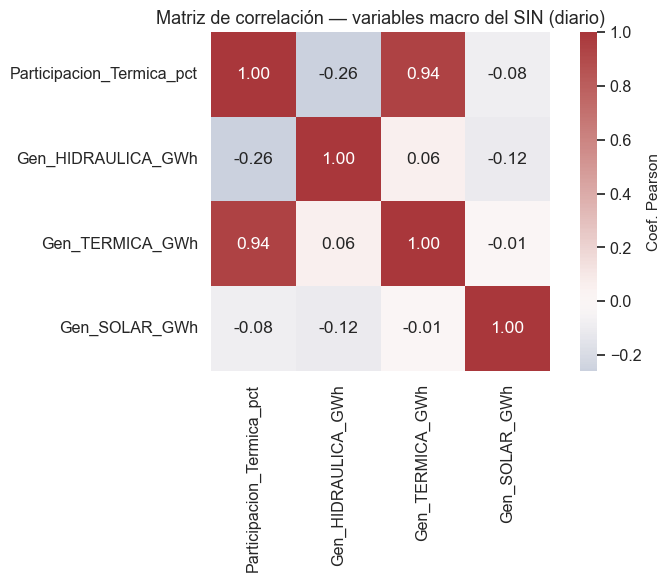

In [21]:
def _tendencia_valida(ax, x: pd.Series, y: pd.Series, color: str) -> float | None:
    """Dibuja tendencia lineal solo si hay suficientes datos y variación."""
    limpio = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(limpio) < 3 or limpio["x"].nunique() < 2 or limpio["y"].nunique() < 2:
        ax.text(0.03, 0.95, "Datos insuficientes para tendencia", transform=ax.transAxes, va="top")
        return None
    m, b = np.polyfit(limpio["x"], limpio["y"], 1)
    xs = np.linspace(limpio["x"].min(), limpio["x"].max(), 100)
    ax.plot(xs, m * xs + b, color=color, linewidth=1.8, linestyle="--")
    return limpio["x"].corr(limpio["y"])


def graficar_correlacion_precio(resumen_diario: pd.DataFrame, guardar: bool = True) -> plt.Figure | None:
    """Explora asociaciones; una correlación no demuestra causalidad."""
    requeridas = {"Precio_Prom_COP", "Nivel_Embalses_Pct"}
    if resumen_diario.empty or not requeridas.issubset(resumen_diario.columns):
        print("⚠️  Faltan columnas para correlación precio")
        return None

    df = resumen_diario.replace([np.inf, -np.inf], np.nan)
    tiene_termica = "Participacion_Termica_pct" in df and df["Participacion_Termica_pct"].notna().any()
    fig, axes = plt.subplots(1, 2 if tiene_termica else 1, figsize=(14 if tiene_termica else 8, 5))
    axes = np.atleast_1d(axes)

    d1 = df.dropna(subset=["Nivel_Embalses_Pct", "Precio_Prom_COP"])
    axes[0].scatter(d1["Nivel_Embalses_Pct"], d1["Precio_Prom_COP"], alpha=0.65, s=55,
                    color=COLORES_METRICA["embalses"], edgecolor="black", linewidth=0.5)
    r1 = _tendencia_valida(axes[0], d1["Nivel_Embalses_Pct"], d1["Precio_Prom_COP"], "#B71C1C")
    axes[0].set_title(f"Precio vs embalses\n(r = {r1:+.2f})" if r1 is not None else "Precio vs embalses")
    axes[0].set_xlabel("Nivel de embalses (%)")
    axes[0].set_ylabel("Precio promedio (COP/kWh)")

    if tiene_termica:
        d2 = df.dropna(subset=["Participacion_Termica_pct", "Precio_Prom_COP"])
        axes[1].scatter(d2["Participacion_Termica_pct"], d2["Precio_Prom_COP"], alpha=0.65, s=55,
                        color=COLORES_TECNO["TERMICA"], edgecolor="black", linewidth=0.5)
        r2 = _tendencia_valida(axes[1], d2["Participacion_Termica_pct"], d2["Precio_Prom_COP"], "#0D47A1")
        axes[1].set_title(f"Precio vs participación térmica\n(r = {r2:+.2f})" if r2 is not None else "Precio vs participación térmica")
        axes[1].set_xlabel("Participación térmica (%)")
        axes[1].set_ylabel("Precio promedio (COP/kWh)")

    for ax in axes:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    fig.suptitle("Asociaciones exploratorias diarias (correlación ≠ causalidad)", y=1.02)
    plt.tight_layout()
    if guardar:
        ruta = FIG_DIR / f"fig_v2_04_correlacion_precio_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


def graficar_matriz_correlacion(resumen_diario: pd.DataFrame, guardar: bool = True) -> plt.Figure | None:
    cols_interes = [
        "Precio_Prom_COP", "Nivel_Embalses_Pct", "Aportes_GWh",
        "Participacion_Termica_pct", "Gen_HIDRAULICA_GWh", "Gen_TERMICA_GWh",
        "Gen_SOLAR_GWh", "Demanda_GWh",
    ]
    cols = [c for c in cols_interes if c in resumen_diario.columns and resumen_diario[c].nunique(dropna=True) > 1]
    if len(cols) < 3:
        return None
    corr = resumen_diario[cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
                square=True, cbar_kws={"label": "Coef. Pearson"}, ax=ax)
    ax.set_title("Matriz de correlación — variables macro del SIN (diario)")
    plt.tight_layout()
    if guardar:
        ruta = FIG_DIR / f"fig_v2_04b_matriz_correlacion_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


fig1 = graficar_correlacion_precio(tablas.get("resumen_diario", pd.DataFrame()))
if fig1: plt.show()
fig2 = graficar_matriz_correlacion(tablas.get("resumen_diario", pd.DataFrame()))
if fig2: plt.show()

### 4.3 Perfil horario de precios: pico vs. valle *(preparación v2.5 SAEB)*

El diferencial entre ventanas horarias fijas es un **indicador exploratorio**. La
viabilidad de un SAEB requiere optimización diaria, eficiencia, degradación,
restricciones de potencia/energía, costos de conexión, liquidación y reglas de
participación. Por eso se reportan el spread bruto y un spread ajustado por
eficiencia, sin convertirlos todavía en una conclusión de inversión.

In [22]:
def graficar_perfil_horario_precios(
    fact_precio: pd.DataFrame,
    horas_pico: tuple[int, int] = HORAS_PICO,
    horas_valle: tuple[int, int] = HORAS_VALLE,
    guardar: bool = True,
) -> tuple[plt.Figure | None, dict]:
    """Boxplot horario y spreads exploratorios bruto/ajustado por eficiencia."""
    if fact_precio.empty or "Precio_COP_kWh" not in fact_precio.columns:
        print("⚠️  Faltan datos para perfil horario de precios")
        return None, {}

    df = fact_precio.dropna(subset=["Hora", "Precio_COP_kWh"]).copy()
    if df.empty:
        return None, {}

    def color_hora(hora: int) -> str:
        if horas_pico[0] <= hora <= horas_pico[1]:
            return "#C62828"
        if horas_valle[0] <= hora <= horas_valle[1]:
            return "#1976D2"
        return "#90A4AE"

    horas_orden = sorted(df["Hora"].astype(int).unique())
    palette = {hora: color_hora(hora) for hora in horas_orden}
    fig, ax = plt.subplots(figsize=(14, 5.5))
    sns.boxplot(data=df, x="Hora", y="Precio_COP_kWh", hue="Hora",
                palette=palette, order=horas_orden, legend=False,
                showfliers=False, ax=ax)
    ax.set_title("Distribución horaria del precio — valle (azul) y pico (rojo)")
    ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")
    ax.set_ylabel("Precio de bolsa (COP/kWh)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    p_pico = df.loc[df["Hora"].between(*horas_pico), "Precio_COP_kWh"].mean()
    p_valle = df.loc[df["Hora"].between(*horas_valle), "Precio_COP_kWh"].mean()
    spread_bruto = p_pico - p_valle
    spread_neto = p_pico - p_valle / EFICIENCIA_RT_SAEB

    kpis = {
        "precio_pico_prom": p_pico,
        "precio_valle_prom": p_valle,
        "spread_bruto_COP_kWh": spread_bruto,
        "spread_ajustado_eficiencia_COP_kWh": spread_neto,
        "eficiencia_rt_referencia": EFICIENCIA_RT_SAEB,
        "horas_pico": horas_pico,
        "horas_valle": horas_valle,
    }

    ax.axhline(p_pico, color="#C62828", linestyle=":", linewidth=1.5, alpha=0.7)
    ax.axhline(p_valle, color="#1976D2", linestyle=":", linewidth=1.5, alpha=0.7)
    ax.text(
        0.02, 0.97,
        f"Pico: {p_pico:,.0f} COP/kWh\nValle: {p_valle:,.0f} COP/kWh\n"
        f"Spread bruto: {spread_bruto:,.0f} COP/kWh\n"
        f"Spread ajustado η={EFICIENCIA_RT_SAEB:.0%}: {spread_neto:,.0f} COP/kWh",
        transform=ax.transAxes, va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
    )

    if guardar:
        ruta = FIG_DIR / f"fig_v2_05_perfil_horario_precios_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    plt.tight_layout()
    return fig, kpis

fig, kpis_saeb = graficar_perfil_horario_precios(tablas.get("fact_precio", pd.DataFrame()))
if fig:
    plt.show()
    print("\n⚡ Inputs exploratorios para v2.5 (SAEB):")
    for clave, valor in kpis_saeb.items():
        print(f"   {clave:42s} = {valor}")

⚠️  Faltan datos para perfil horario de precios


---
## 🌊 Sección 5 — Contexto hídrico y seguridad del sistema

### 5.1 Nivel de embalses con bandas exploratorias

`PorcVoluUtilDiar` expresa el volumen útil agregado como porcentaje. Las bandas
60%/40% usadas abajo son **umbrales visuales configurables para exploración**;
no son declaraciones oficiales de alerta, racionamiento ni activación del Cargo
por Confiabilidad. Cualquier uso operativo debe contrastarse con publicaciones realizadas por XM.

| Banda analítica | Nivel | Uso en este notebook |
|:--|:--|:--|
| Normal | > 60% | Referencia visual |
| Seguimiento | 40–60% | Revisar tendencia y aportes |
| Estrés | < 40% | Priorizar análisis de escenarios |

In [23]:
def graficar_embalses_zonas(
    fact_embalses: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Nivel de embalses con axhspan de zonas de alerta y anotación del mínimo."""
    if fact_embalses.empty or "Nivel_Embalses_Pct" not in fact_embalses.columns:
        print("⚠️  Faltan datos de embalses")
        return None

    df = fact_embalses.dropna(subset=["Nivel_Embalses_Pct"]).copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    fig, ax = plt.subplots(figsize=(15, 5.5))

    # Zonas de alerta (bandas horizontales)
    ax.axhspan(UMBRAL_EMBALSES_ALERTA, 100, facecolor="#4CAF50", alpha=0.12, label="Zona normal (>60%)")
    ax.axhspan(UMBRAL_EMBALSES_CRITICO, UMBRAL_EMBALSES_ALERTA,
               facecolor="#FFC107", alpha=0.15, label="Seguimiento (40–60%)")
    ax.axhspan(0, UMBRAL_EMBALSES_CRITICO, facecolor="#F44336", alpha=0.15, label="Estrés (<40%)")

    ax.plot(df["Fecha"], df["Nivel_Embalses_Pct"],
            color=COLORES_METRICA["embalses"], linewidth=2.2, marker="o", markersize=3)

    # Anotación del mínimo
    idx_min = df["Nivel_Embalses_Pct"].idxmin()
    fecha_min = df.loc[idx_min, "Fecha"]
    val_min   = df.loc[idx_min, "Nivel_Embalses_Pct"]
    ax.annotate(
        f"Mínimo: {val_min:.1f}%\n{fecha_min:%d %b}",
        xy=(fecha_min, val_min),
        xytext=(fecha_min, val_min - 8),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=10, ha="center",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
    )

    ax.set_title(f"Nivel de Embalses del SIN — {df['Fecha'].min():%d %b} a {df['Fecha'].max():%d %b %Y}")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Volumen útil (%)")
    ax.set_ylim(max(0, df["Nivel_Embalses_Pct"].min() - 15), 100)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, len(df)//10)))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(loc="lower left")
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_06_embalses_zonas_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


In [24]:
# Genero la grafica de embalses con zonas de alerta y crítico, si hay datos disponibles
fig = graficar_embalses_zonas(tablas.get("fact_embalses", pd.DataFrame()))
if fig:
    plt.show()

⚠️  Faltan datos de embalses


### 5.2 Aportes hídricos + correlación con embalses

Los aportes de energía hídrica (`AporEner`) miden la energía potencial que ingresa a los embalses desde los ríos. Es la variable macro más importante para proyectar el estado futuro del sistema.

- **Panel A:** Serie temporal de aportes diarios + media móvil de 7 días.
- **Panel B:** Aportes vs. cambio diario en el nivel de embalses (`delta_embalses`).

In [25]:
def graficar_aportes_y_delta(
    fact_aportes: pd.DataFrame,
    fact_embalses: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Panel A: aportes diarios + MM7. Panel B: aportes vs delta de embalses."""
    requeridas = {"Fecha", "Aportes_kWh"}
    if fact_aportes.empty or not requeridas.issubset(fact_aportes.columns):
        print("⚠️  Faltan datos de aportes")
        return None

    ap = fact_aportes.dropna(subset=["Fecha", "Aportes_kWh"]).copy()
    ap["Fecha"] = pd.to_datetime(ap["Fecha"])
    ap["Aportes_GWh"] = ap["Aportes_kWh"] / 1e6
    ap = ap.sort_values("Fecha").reset_index(drop=True)
    ap["MM7"] = ap["Aportes_GWh"].rolling(window=7, min_periods=1).mean()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].bar(ap["Fecha"], ap["Aportes_GWh"], color=COLORES_METRICA["aportes"],
                alpha=0.55, label="Aportes diarios")
    axes[0].plot(ap["Fecha"], ap["MM7"], color="#33691E", linewidth=2.2,
                 label="Media móvil 7 días")
    axes[0].set_title("Aportes hídricos diarios (GWh) + MM7")
    axes[0].set_xlabel("Fecha")
    axes[0].set_ylabel("Aportes (GWh/día)")
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")
    axes[0].legend()

    ax = axes[1]
    if not fact_embalses.empty and {"Fecha", "Nivel_Embalses_Pct"}.issubset(fact_embalses.columns):
        emb = fact_embalses.dropna(subset=["Fecha", "Nivel_Embalses_Pct"]).copy()
        emb["Fecha"] = pd.to_datetime(emb["Fecha"])
        emb = emb.sort_values("Fecha").reset_index(drop=True)
        emb["Delta_Embalses"] = emb["Nivel_Embalses_Pct"].diff()
        merged = ap.merge(emb[["Fecha", "Delta_Embalses"]], on="Fecha", how="inner").dropna()
        if len(merged) >= 3:
            ax.scatter(merged["Aportes_GWh"], merged["Delta_Embalses"],
                       alpha=0.7, s=55, color=COLORES_METRICA["embalses"], edgecolor="black", linewidth=0.5)
            x, y = merged["Aportes_GWh"], merged["Delta_Embalses"]
            r = _tendencia_valida(ax, x, y, "#B71C1C")
            ax.axhline(0, color="black", linewidth=0.5, alpha=0.5)
            titulo_r = f" (r = {r:+.2f})" if r is not None else ""
            ax.set_title(f"Aportes vs Δ embalses diario{titulo_r}")
            ax.set_xlabel("Aportes (GWh/día)")
            ax.set_ylabel("Δ nivel embalses (p.p./día)")
        else:
            ax.text(0.5, 0.5, "Se requieren al menos 3 días comunes",
                    ha="center", va="center", transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, "No hay datos de embalses",
                ha="center", va="center", transform=ax.transAxes)

    plt.tight_layout()
    if guardar:
        ruta = FIG_DIR / f"fig_v2_07_aportes_delta_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig

In [26]:
# Se genera la grafica de aportes y delta de embalses, si hay datos disponibles
fig = graficar_aportes_y_delta(
    tablas.get("fact_aportes", pd.DataFrame()),
    tablas.get("fact_embalses", pd.DataFrame()),
)
if fig:
    plt.show()

⚠️  Faltan datos de aportes


---
## 🔥 Sección 6 — Perfil Horario Consolidado (Heatmaps)

### 6.1 Heatmap: generación por tecnología × hora del día

Mapa de calor que muestra la generación **promedio** por hora del día para cada tecnología. Revela los patrones intra-día característicos:
- **Solar** se concentra en 06h–18h con pico al mediodía.
- **Térmica** pica en horas punta (18h–22h).
- **Hidráulica** hace de balance seguidor de la demanda residual.

In [27]:
def graficar_heatmap_tecno_hora(
    gen_enriquecida: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Heatmap del total tecnológico horario promedio entre días."""
    requeridas = {"Tecnologia", "Fecha", "Hora", "Generacion_kWh"}
    if gen_enriquecida.empty or not requeridas.issubset(gen_enriquecida.columns):
        print("⚠️  Faltan datos enriquecidos para heatmap")
        return None

    # Primero total por tecnología-fecha-hora; después promedio entre días.
    # Esto evita promediar plantas individuales y etiquetarlo como total tecnológico.
    tecno_h_dia = (
        gen_enriquecida.groupby(["Tecnologia", "Fecha", "Hora"], as_index=False)["Generacion_kWh"]
        .sum(min_count=1)
    )
    pivot = (
        tecno_h_dia.groupby(["Tecnologia", "Hora"])["Generacion_kWh"]
        .mean().div(1e6)
        .unstack(fill_value=0)
    )
    orden = tecno_h_dia.groupby("Tecnologia")["Generacion_kWh"].sum().sort_values(ascending=False).index
    pivot = pivot.reindex(orden)

    fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.7)))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd",
                cbar_kws={"label": "Generación tecnológica promedio (GWh/h)"},
                linewidths=0.3, ax=ax)
    ax.set_title("Perfil horario de generación total por tecnología (promedio diario)")
    ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")
    ax.set_ylabel("Tecnología")
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_08_heatmap_tecno_hora_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig

💾 Figura guardada: fig_v2_08_heatmap_tecno_hora_20260510_20260607.png


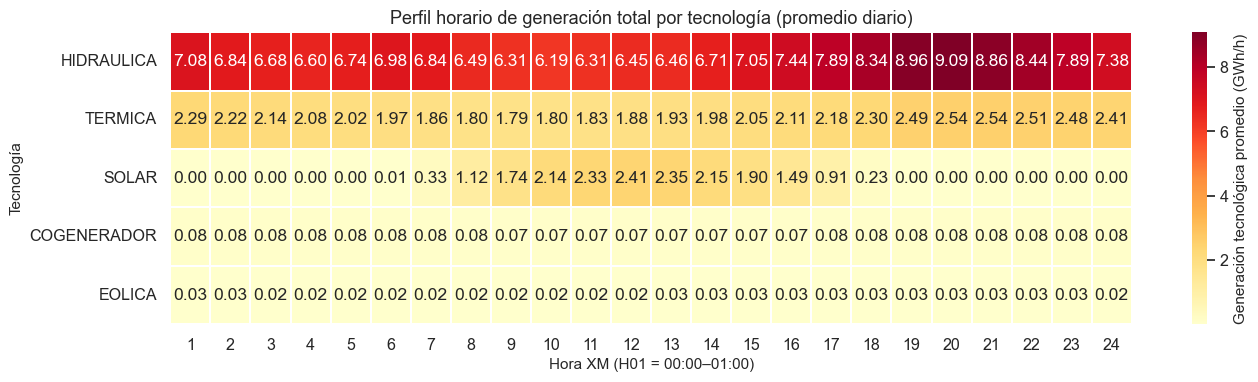

In [28]:
# Se genera la grafica de heatmap de generación por tecnología y hora, si hay datos disponibles
fig = graficar_heatmap_tecno_hora(tablas.get("gen_enriquecida", pd.DataFrame()))
if fig:
    plt.show()

### 6.2 Heatmap: precio de bolsa hora × día

Visualización de la volatilidad intra-día del precio a lo largo del período completo. Un patrón vertical **rojo consistente en 18h–22h** confirma la ventana de arbitraje SAEB.

In [29]:
def graficar_heatmap_precio_dia_hora(
    fact_precio: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Heatmap Día × Hora del precio de bolsa (colormap divergente)."""
    if fact_precio.empty:
        print("⚠️  Faltan datos de precio para heatmap")
        return None

    df = fact_precio.copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    pivot = df.pivot_table(index="Fecha", columns="Hora",
                           values="Precio_COP_kWh", aggfunc="mean")

    n_dias = pivot.shape[0]
    fig, ax = plt.subplots(figsize=(16, max(8, n_dias * 0.3)))
    sns.heatmap(pivot, cmap="RdYlGn_r", ax=ax,
                cbar_kws={"label": "Precio (COP/kWh)"},
                linewidths=0.15, linecolor="white")
    ax.set_title("Precio de bolsa — heatmap día × hora (verde=barato, rojo=caro)")
    ax.set_xlabel("Hora del día"); ax.set_ylabel("Fecha")
    # Formatear fechas del eje Y
    ax.set_yticklabels([d.strftime("%d %b") for d in pivot.index], rotation=0)
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_09_heatmap_precio_dia_hora_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig

In [30]:
# Se genera la grafica de heatmap de precio por día y hora, si hay datos disponibles
fig = graficar_heatmap_precio_dia_hora(tablas.get("fact_precio", pd.DataFrame()))
if fig:
    plt.show()

⚠️  Faltan datos de precio para heatmap


### 6.3 Perfil solar: días laborables vs. fines de semana

Esta comparación permite explorar si el perfil horario de la generación solar presenta diferencias sistemáticas según el tipo de día. Aunque la producción fotovoltaica depende principalmente de la irradiancia y de las condiciones meteorológicas, la clasificación entre días laborables y fines de semana aporta contexto para estudiar su interacción con los patrones de consumo y la generación distribuida.

Los resultados deben interpretarse como una comparación descriptiva del período analizado, no como evidencia de que el tipo de día determina directamente la generación solar.

In [31]:
def graficar_perfil_solar_semana(
    gen_enriquecida: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Compara la generación solar total horaria por tipo de día."""
    requeridas = {"Tecnologia", "Fecha", "Hora", "Generacion_kWh"}
    if gen_enriquecida.empty or not requeridas.issubset(gen_enriquecida.columns):
        return None
    solar = gen_enriquecida[gen_enriquecida["Tecnologia"].eq("SOLAR")].copy()
    if solar.empty:
        print("ℹ️  No hay generación solar en el período — se omite el gráfico.")
        return None
    solar["Fecha"] = pd.to_datetime(solar["Fecha"])
    solar["Tipo_Dia"] = np.where(solar["Fecha"].dt.dayofweek >= 5, "Fin de semana", "Laborable")

    solar_dia_h = (
        solar.groupby(["Tipo_Dia", "Fecha", "Hora"], as_index=False)["Generacion_kWh"]
        .sum(min_count=1)
    )
    perfil = (
        solar_dia_h.groupby(["Tipo_Dia", "Hora"])["Generacion_kWh"]
        .mean().div(1e6)
        .reset_index(name="Gen_GWh_prom")
    )

    fig, ax = plt.subplots(figsize=(12, 4.5))
    for tipo, color in [("Laborable", "#1976D2"), ("Fin de semana", "#F57C00")]:
        sub = perfil[perfil["Tipo_Dia"] == tipo]
        ax.plot(sub["Hora"], sub["Gen_GWh_prom"], marker="o", linewidth=2,
                color=color, label=tipo)
    ax.set_title("Perfil horario de generación solar total: laborables vs fines de semana")
    ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")
    ax.set_ylabel("Generación solar promedio (GWh/h)")
    ax.set_xticks(range(1, 25))
    ax.legend()
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_10_perfil_solar_semana_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


💾 Figura guardada: fig_v2_10_perfil_solar_semana_20260510_20260607.png


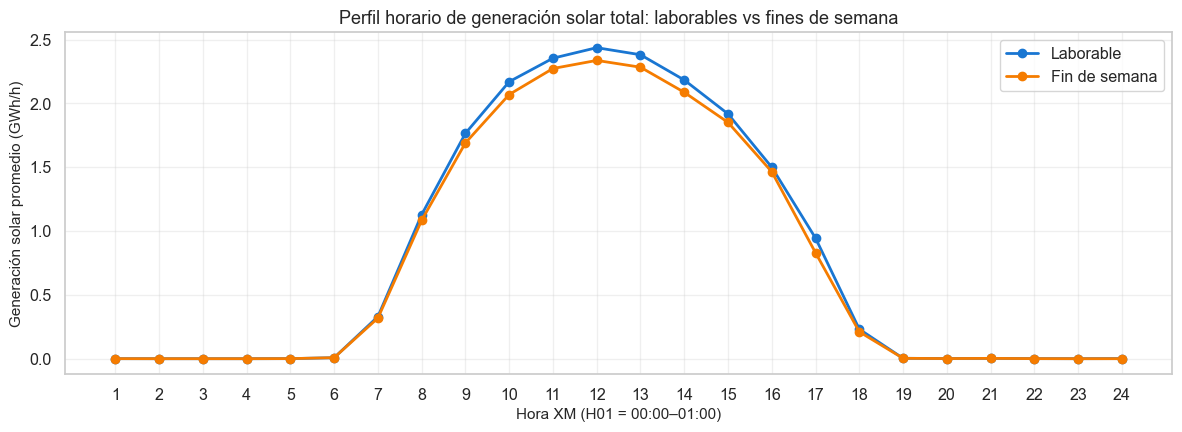

In [32]:
# Se genera la grafica de perfil solar por tipo de día, si hay datos disponibles
fig = graficar_perfil_solar_semana(tablas.get("gen_enriquecida", pd.DataFrame()))
if fig:
    plt.show()

---
## 📋 Sección 7 — Resumen Ejecutivo y Preparación para v2.5 (SAEB)

### 7.1 Exportar tablas procesadas

Todas las tablas analíticas se guardan en `data/processed/` con estampa `YYYYMMDD_YYYYMMDD` (rango del período) para que v2.5 las consuma.

In [33]:
# ── Guardar outputs en data/processed/ ────────────────────────────────────────
tablas_a_exportar = {
    "fact_generacion":     tablas.get("fact_generacion",     pd.DataFrame()),
    "fact_demanda":        tablas.get("fact_demanda",        pd.DataFrame()),
    "fact_precio":         tablas.get("fact_precio",         pd.DataFrame()),
    "fact_embalses":       tablas.get("fact_embalses",       pd.DataFrame()),
    "fact_aportes":        tablas.get("fact_aportes",        pd.DataFrame()),
    "fact_precio_escasez": tablas.get("fact_precio_escasez", pd.DataFrame()),
    "gen_enriquecida":     tablas.get("gen_enriquecida",     pd.DataFrame()),
    "sistema_h":           tablas.get("sistema_h",           pd.DataFrame()),
    "resumen_diario":      tablas.get("resumen_diario",      pd.DataFrame()),
}

print(f"💾 Exportando tablas procesadas (etiqueta: {ETIQUETA_PERIODO})...\n")

for nombre, df in tablas_a_exportar.items():
    if df.empty:
        print(f"  ⏭️   {nombre:20s} — vacío, se omite")
        continue
    ruta = PROCESSED_DIR / f"{nombre}_{ETIQUETA_PERIODO}.csv"
    df.to_csv(ruta, index=False)
    print(f"  ✅ {nombre:20s} → {ruta.name} ({df.shape[0]:>7,} filas)")

print(f"\n✅ Todos los outputs guardados en {PROCESSED_DIR}")

💾 Exportando tablas procesadas (etiqueta: 20260510_20260607)...

  ✅ fact_generacion      → fact_generacion_20260510_20260607.csv (318,624 filas)
  ⏭️   fact_demanda         — vacío, se omite
  ⏭️   fact_precio          — vacío, se omite
  ⏭️   fact_embalses        — vacío, se omite
  ⏭️   fact_aportes         — vacío, se omite
  ⏭️   fact_precio_escasez  — vacío, se omite
  ✅ gen_enriquecida      → gen_enriquecida_20260510_20260607.csv (318,624 filas)
  ✅ sistema_h            → sistema_h_20260510_20260607.csv (    696 filas)
  ✅ resumen_diario       → resumen_diario_20260510_20260607.csv (     29 filas)

✅ Todos los outputs guardados en G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\processed


### 7.2 Resumen cuantitativo reproducible

La celda siguiente genera hallazgos desde los datos ejecutados. Si una métrica no
está disponible, se reporta explícitamente en vez de completar un valor manual o
inferirlo. Los resultados son descriptivos del período común analizado.

In [34]:
def construir_hallazgos(
    resumen: pd.DataFrame,
    sistema: pd.DataFrame,
    kpis_precio: dict,
) -> pd.DataFrame:
    filas = []

    def agregar(indicador: str, valor, unidad: str, interpretacion: str) -> None:
        filas.append({"Indicador": indicador, "Valor": valor, "Unidad": unidad,
                      "Interpretación": interpretacion})

    if "Balance_GWh" in resumen:
        serie = resumen["Balance_GWh"].dropna()
        if not serie.empty:
            agregar("Gap generación-demanda promedio", round(serie.mean(), 2), "GWh/día",
                    "Diagnóstico de consistencia; no equivale por sí solo a exportación.")
    if {"Hora", "Gap_Gen_Dem_kWh"}.issubset(sistema.columns):
        perfil_gap = sistema.groupby("Hora")["Gap_Gen_Dem_kWh"].mean()
        if not perfil_gap.empty:
            agregar("Hora XM con gap promedio mínimo", int(perfil_gap.idxmin()), "H01–H24",
                    "H01 representa 00:00–01:00.")
    if {"Precio_Prom_COP", "Nivel_Embalses_Pct"}.issubset(resumen.columns):
        r = resumen[["Precio_Prom_COP", "Nivel_Embalses_Pct"]].corr().iloc[0, 1]
        agregar("Correlación precio-embalses", round(r, 3), "Pearson r",
                "Asociación del período; no prueba causalidad.")
    if {"Precio_Prom_COP", "Participacion_Termica_pct"}.issubset(resumen.columns):
        r = resumen[["Precio_Prom_COP", "Participacion_Termica_pct"]].corr().iloc[0, 1]
        agregar("Correlación precio-participación térmica", round(r, 3), "Pearson r",
                "Asociación del período; sensible a variables omitidas.")
    if "Nivel_Embalses_Pct" in resumen:
        nivel = resumen["Nivel_Embalses_Pct"].dropna()
        if not nivel.empty:
            agregar("Nivel mínimo de embalses", round(nivel.min(), 2), "%",
                    "Comparar con contexto operativo oficial del período.")
            agregar("Días bajo banda exploratoria de 60%", int((nivel < UMBRAL_EMBALSES_ALERTA).sum()), "días",
                    "Umbral gráfico, no alerta regulatoria.")
    if kpis_precio:
        agregar("Spread bruto pico-valle", round(kpis_precio["spread_bruto_COP_kWh"], 2), "COP/kWh",
                "Input exploratorio para v2.5.")
        agregar("Spread ajustado por eficiencia", round(kpis_precio["spread_ajustado_eficiencia_COP_kWh"], 2), "COP/kWh",
                "Aún no incluye degradación, CAPEX, OPEX ni restricciones operativas.")

    if not filas:
        filas.append({"Indicador": "Datos v2 no disponibles", "Valor": np.nan, "Unidad": "—",
                      "Interpretación": "Cargue demanda, precio, embalses y aportes para completar el resumen."})
    return pd.DataFrame(filas)


hallazgos_v2 = construir_hallazgos(
    tablas.get("resumen_diario", pd.DataFrame()),
    tablas.get("sistema_h", pd.DataFrame()),
    globals().get("kpis_saeb", {}),
)
display(hallazgos_v2)
ruta_hallazgos = PROCESSED_DIR / f"hallazgos_v2_{ETIQUETA_PERIODO}.csv"
hallazgos_v2.to_csv(ruta_hallazgos, index=False)
print(f"💾 Hallazgos exportados: {ruta_hallazgos.name}")

,Indicador,Valor,Unidad,Interpretación
0,Datos v2 no disponibles,NaN,—,"Cargue demanda, precio, embalses y aportes par..."


💾 Hallazgos exportados: hallazgos_v2_20260510_20260607.csv


### 7.3 Preparación para v2.5 — SAEB (Resolución CREG 101 113 de 2026)

La resolución vigente define reglas de instalación, operación y aspectos
comerciales de los SAEB en el SIN. Este notebook solo prepara datos de mercado;
no reemplaza el modelado operativo ni el análisis regulatorio/económico de v2.5.

| Dato de v2 | Archivo consumible | Uso posterior |
|:--|:--|:--|
| Precio horario | `fact_precio_*.csv` | Optimización de carga/descarga |
| Demanda horaria | `fact_demanda_*.csv` | Contexto de ventanas operativas |
| Embalses | `fact_embalses_*.csv` | Escenarios de estrés hídrico |
| Participación térmica | `resumen_diario_*.csv` | Contexto de emisiones, con supuestos explícitos |
| Hallazgos | `hallazgos_v2_*.csv` | Trazabilidad de KPIs del período |

Fuentes oficiales consultadas:

- [Resolución CREG 101 113 de 2026](https://gestornormativo.creg.gov.co/gestor/entorno/docs/resolucion_creg_101-113_2026.htm)
- [XM — precio de bolsa y precio de escasez](https://www.xm.com.co/transacciones/cargo-por-confiabilidad/precio-de-bolsa-y-escasez)

---

### 7.4 Estado del roadmap

| Versión | Enfoque | Estado |
|:--|:--|:--|
| v1 | ETL + EDA de generación | Completada |
| v2 | Series, balance, precio e hidrología | Lista para validar con las seis métricas |
| v2.5 | Simulación y caso SAEB | Siguiente entrega |
| v3 | Capacidad, emisiones y factor de planta | Planeada |
| v4 | Dashboard Streamlit | Planeada |
| v5 | Predicción y desviaciones | Planeada |